# Regresion lineal en series de tiempo

## Carga de paquetes

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.sandbox.stats.runs import runstest_1samp # prueba de rachas de Wald y Wolfowitz
import statsmodels.api as sm # prueba de Box-Pierce y la modificación de Ljung-Box
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pylab as py
from scipy import stats
from datetime import datetime
from dateutil.relativedelta import relativedelta

## Carga de datos

In [ ]:
df_empleo= pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
df_empleo.head()
df_empleo.shape

(222, 4)

## Particion de datos entre entrenamiento y prueba

In [ ]:
train_len = 216
train_td = df_empleo[["Ocupados"]][:train_len]
test_td  = df_empleo[["Ocupados"]][train_len:]

## Tendencia lineal

In [ ]:
y = train_td["Ocupados"].values
x = np.linspace(1,train_td.shape[0],train_td.shape[0])
X = sm.add_constant(x)
lin = sm.OLS(y,X)
lin_t = lin.fit()
print(lin_t.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     5386.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          1.10e-153
Time:                        09:44:07   Log-Likelihood:                -1500.2
No. Observations:                 216   AIC:                             3004.
Df Residuals:                     214   BIC:                             3011.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6925.6150     34.477    200.879      0.0

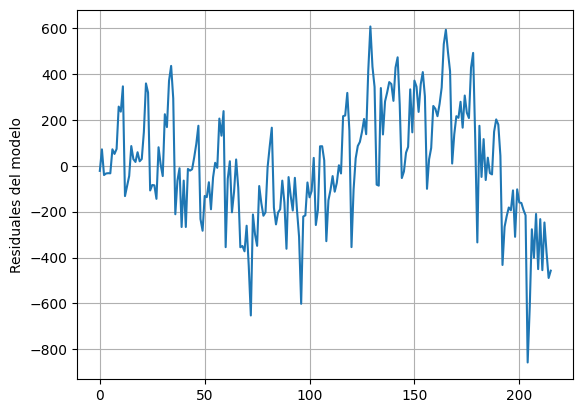

In [ ]:
plt.ylabel("Residuales del modelo")
plt.plot(lin_t.resid)
plt.grid()

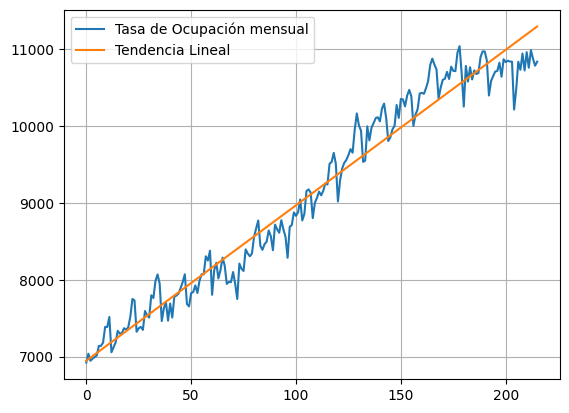

In [ ]:
plt.plot(y,label="Tasa de Ocupación mensual")
plt.plot(lin_t.fittedvalues,label="Tendencia Lineal")
plt.legend()
plt.grid()
plt.show()

In [ ]:
h=6
x_for= np.linspace((train_td.shape[0]+1),(train_td.shape[0]+h),h)
X_for= sm.add_constant(x_for)

In [ ]:
dt = lin_t.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

   Point_forecast      lower_95      upper_95
0    11313.116341  10810.849071  11815.383612
1    11333.335242  10831.003977  11835.666506
2    11353.554142  10851.158304  11855.949979
3    11373.773042  10871.312053  11876.234030
4    11393.991942  10891.465223  11896.518660
5    11414.210842  10911.617816  11916.803868


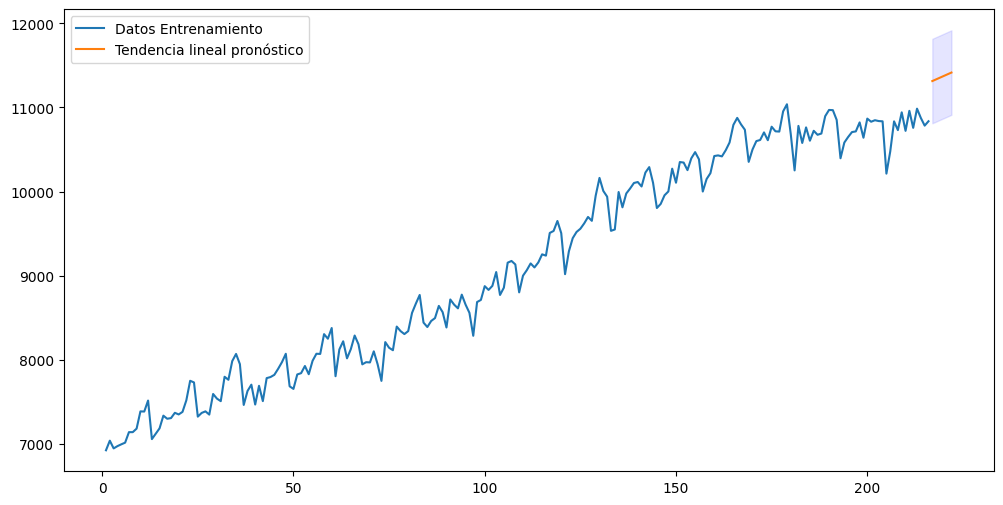

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.plot(x,y,label="Datos Entrenamiento")
plt.plot(x_for,preds['Point_forecast'],label="Tendencia lineal pronóstico")
plt.fill_between(x_for ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

### Metricas

In [ ]:
rmse_add = np.sqrt(mean_squared_error(
    test_td, preds['Point_forecast']
))
print(rmse_add)

725.5285275153046


## Tendencia cuadratica

In [ ]:
y = train_td["Ocupados"]
train_td["x"] = np.linspace(1,train_td.shape[0],train_td.shape[0])
train_td["x2"] = train_td["x"]**2
X = sm.add_constant(train_td[["x","x2"]])
pol = sm.OLS(y,X)
pol_2 = pol.fit()
print(pol_2.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     2752.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          6.85e-153
Time:                        09:44:09   Log-Likelihood:                -1497.5
No. Observations:                 216   AIC:                             3001.
Df Residuals:                     213   BIC:                             3011.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6835.5053     51.482    132.774      0.0

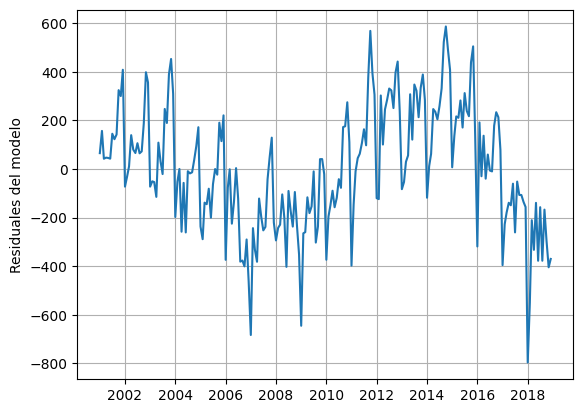

In [ ]:
plt.ylabel("Residuales del modelo")
plt.plot(pol_2.resid)
plt.grid()

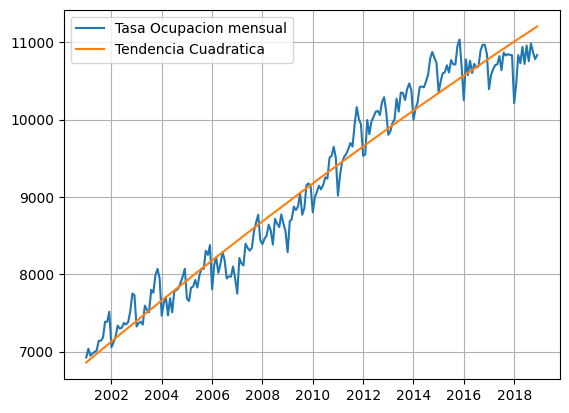

In [ ]:
plt.plot(y,label="Tasa Ocupacion mensual")
plt.plot(pol_2.fittedvalues,label="Tendencia Cuadratica")
plt.legend()
plt.grid()
plt.show()

In [ ]:
h=6
x_for= np.linspace((train_td.shape[0]+1),(train_td.shape[0]+h),h)
X_for= sm.add_constant(np.stack((x_for, x_for**2), axis=1))

In [ ]:
dt = pol_2.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

   Point_forecast      lower_95      upper_95
0    11223.006575  10720.110033  11725.903118
1    11240.733961  10737.453096  11744.014826
2    11258.438489  10754.761188  11762.115790
3    11276.120159  10772.034093  11780.206225
4    11293.778971  10789.271596  11798.286346
5    11311.414925  10806.473482  11816.356368


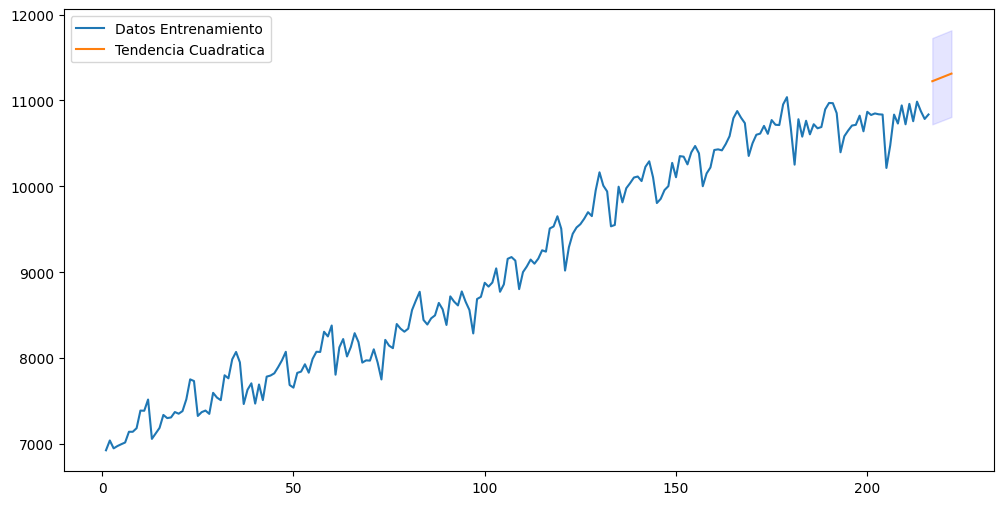

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.plot(x,y,label="Datos Entrenamiento")
plt.plot(x_for,preds['Point_forecast'],label="Tendencia Cuadratica")
plt.fill_between(x_for ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

## Metricas

In [ ]:
rmse_add = np.sqrt(mean_squared_error(
    test_td, preds['Point_forecast']
))
print(rmse_add)

632.4766573075538


## Tendencia cubica

In [ ]:
y = train_td["Ocupados"]
train_td["x"] = np.linspace(1,train_td.shape[0],train_td.shape[0])
train_td["x2"] = train_td["x"]**2
train_td["x3"] = train_td["x"]**3
X = sm.add_constant(train_td[["x","x2","x3"]])
pol = sm.OLS(y,X)
pol_3 = pol.fit()
print(pol_3.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     2949.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          1.62e-172
Time:                        09:44:10   Log-Likelihood:                -1447.3
No. Observations:                 216   AIC:                             2903.
Df Residuals:                     212   BIC:                             2916.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7247.0943     54.981    131.810      0.0

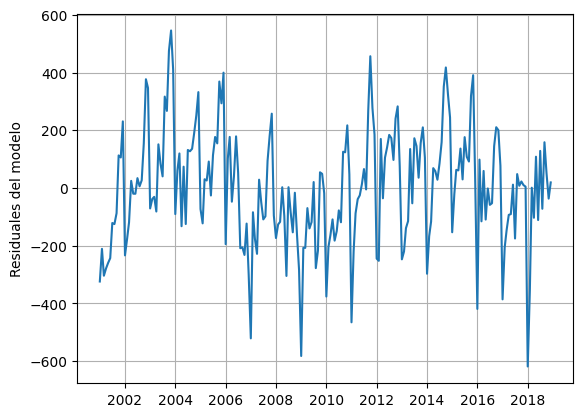

In [ ]:
plt.ylabel("Residuales del modelo")
plt.plot(pol_3.resid)
plt.grid()

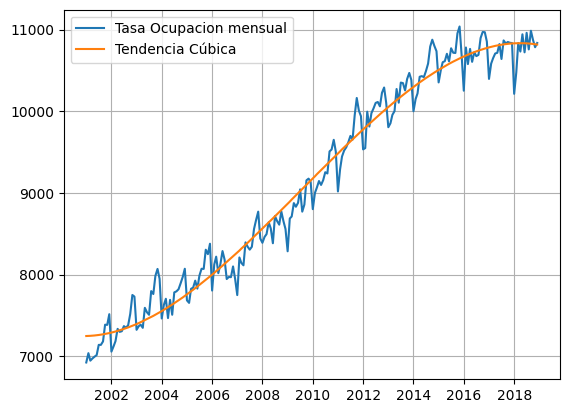

In [ ]:
plt.plot(y,label="Tasa Ocupacion mensual")
plt.plot(pol_3.fittedvalues,label="Tendencia Cúbica")
plt.legend()
plt.grid()
plt.show()

In [ ]:
h=6
x_for= np.linspace((train_td.shape[0]+1),(train_td.shape[0]+h),h)
X_for= sm.add_constant(np.stack((x_for, x_for**2, x_for**3), axis=1))

In [ ]:
dt = pol_3.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

   Point_forecast      lower_95      upper_95
0    10811.417558  10405.366847  11217.468269
1    10806.384261  10399.300100  11213.468423
2    10800.806072  10392.623991  11208.988153
3    10794.678224  10385.331151  11204.025296
4    10787.995948  10377.414174  11198.577723
5    10780.754479  10368.865618  11192.643339


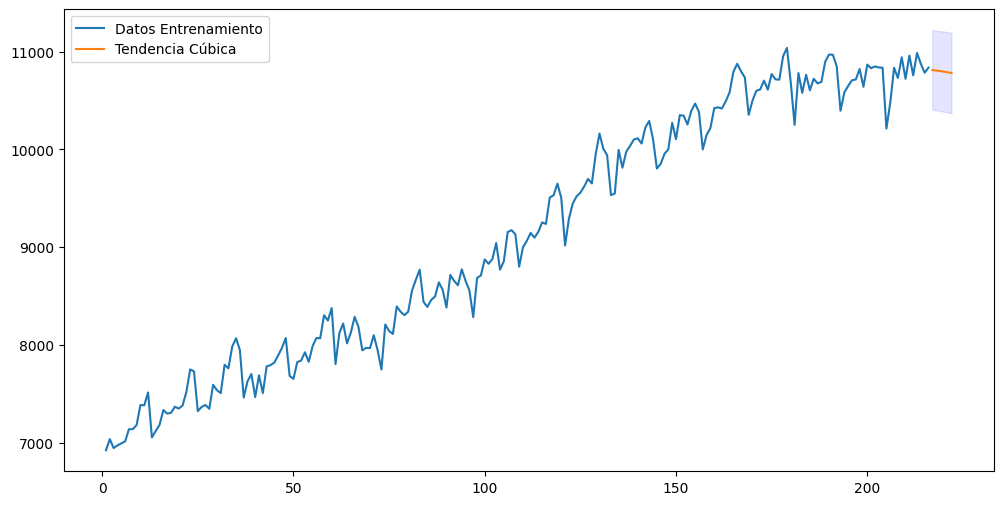

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.plot(x,y,label="Datos Entrenamiento")
plt.plot(x_for,preds['Point_forecast'],label="Tendencia Cúbica")
plt.fill_between(x_for ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

## Metricas

In [ ]:
rmse_add = np.sqrt(mean_squared_error(
    test_td, preds['Point_forecast']
))
print(rmse_add)

238.72205796222684


## Estacionalidad - dummies

In [ ]:
month_dummies = pd.get_dummies(train_td.index.month,drop_first=True, dtype=float).set_index(train_td.index)

y = train_td["Ocupados"]
X = sm.add_constant(month_dummies)
sea = sm.OLS(y,X)
season = sea.fit()
print(season.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                 -0.032
Method:                 Least Squares   F-statistic:                    0.3897
Date:                Thu, 04 Jun 2026   Prob (F-statistic):              0.959
Time:                        09:44:11   Log-Likelihood:                -1850.6
No. Observations:                 216   AIC:                             3725.
Df Residuals:                     204   BIC:                             3766.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8724.5387    308.558     28.275      0.0

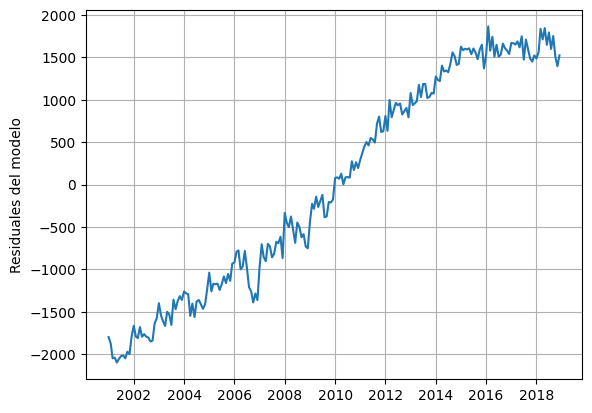

In [ ]:
plt.ylabel("Residuales del modelo")
plt.plot(season.resid)
plt.grid()

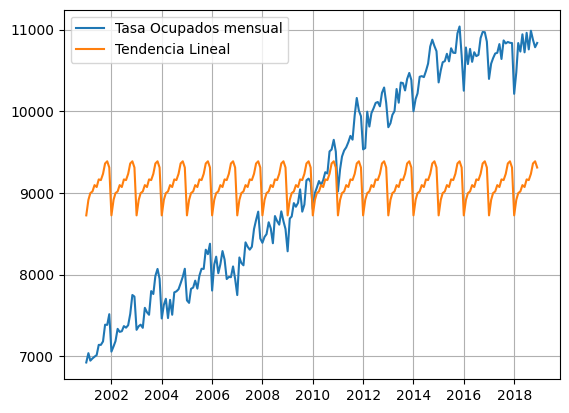

In [ ]:
plt.plot(y,label="Tasa Ocupados mensual")
plt.plot(season.fittedvalues,label="Tendencia Lineal")
plt.legend()
plt.grid()
plt.show()

In [ ]:
range_dates = pd.date_range(train_td.index[-1]+ relativedelta(months=1), periods=6,freq='MS')

x_for = pd.get_dummies(range_dates.month,drop_first=True, dtype=float)
X_for= sm.add_constant(x_for)

In [ ]:
# Alinear columnas con las del entrenamiento
x_for = x_for.reindex(columns=month_dummies.columns, fill_value=0)

# Agregar constante
X_for = sm.add_constant(x_for, has_constant="add")

# Predicción
dt = season.get_prediction(X_for).summary_frame(alpha=0.05)

preds = pd.DataFrame({
    "Point_forecast": dt["mean"].values,
    "lower_95": dt["obs_ci_lower"].values,
    "upper_95": dt["obs_ci_upper"].values
}, index=range_dates)

print(preds)

            Point_forecast     lower_95      upper_95
2019-01-01     8724.538722  6072.708767  11376.368678
2019-02-01     8914.544389  6262.714433  11566.374344
2019-03-01     8997.218333  6345.388378  11649.048289
2019-04-01     9017.681722  6365.851767  11669.511678
2019-05-01     9095.089000  6443.259045  11746.918955
2019-06-01     9071.789000  6419.959045  11723.618955


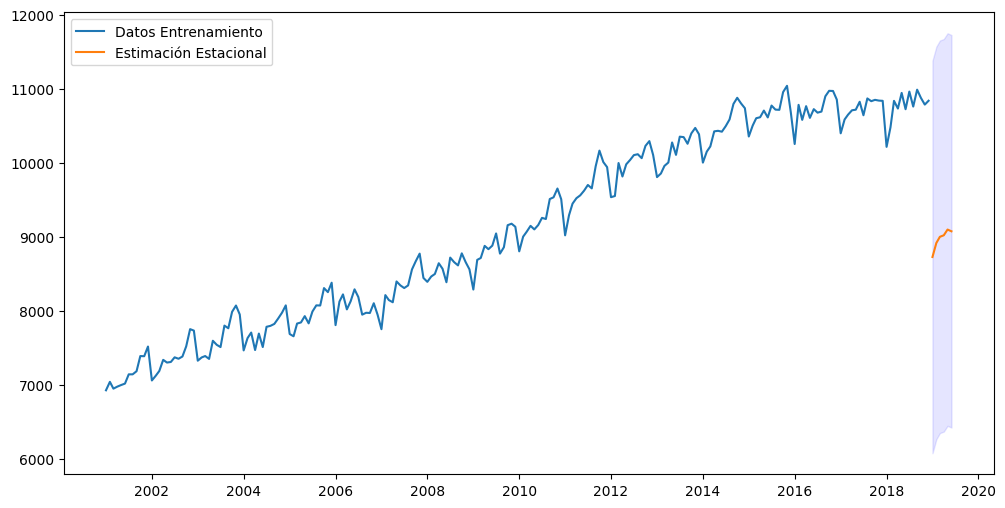

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.plot(y.index,y,label="Datos Entrenamiento")
plt.plot(preds.index,preds['Point_forecast'],label="Estimación Estacional")
plt.fill_between(preds.index,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()
     

In [ ]:
rmse_add = np.sqrt(mean_squared_error(
    test_td, preds['Point_forecast']
))
print(rmse_add)

1685.7662214902116


## Tendencia cubica + Estacionalidad

In [ ]:
y = train_td["Ocupados"]
train_td["x"] = np.linspace(1,train_td.shape[0],train_td.shape[0])
train_td["x2"] = train_td["x"]**2
train_td["x3"] = train_td["x"]**3

month_dummies = pd.get_dummies(train_td.index.month,drop_first=True, dtype=float).set_index(train_td.index)
X = sm.add_constant( pd.concat([train_td[["x","x2","x3"]],month_dummies],axis=1) )

season_pol3 = sm.OLS(y,X)
season_pol_3 = season_pol3.fit()
print(season_pol_3.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     1096.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          2.56e-181
Time:                        09:44:13   Log-Likelihood:                -1383.2
No. Observations:                 216   AIC:                             2796.
Df Residuals:                     201   BIC:                             2847.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6980.7137     53.194    131.232      0.0

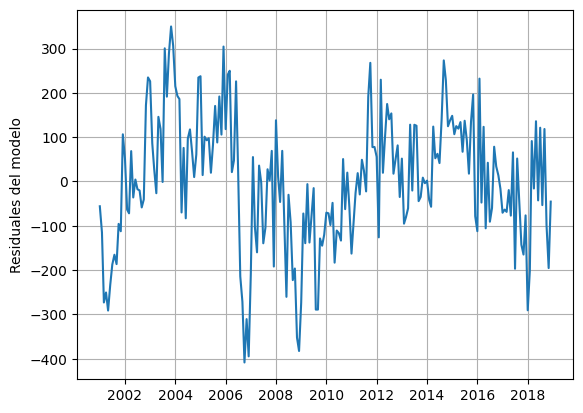

In [ ]:
plt.ylabel("Residuales del modelo")
plt.plot(season_pol_3.resid)
plt.grid()

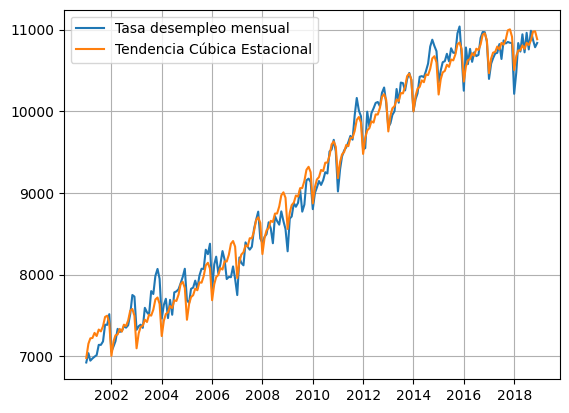

In [ ]:
plt.plot(y,label="Tasa desempleo mensual")
plt.plot(season_pol_3.fittedvalues,label="Tendencia Cúbica Estacional")
plt.legend()
plt.grid()
plt.show()

In [ ]:
h=6
x_for= np.linspace((train_td.shape[0]+1),(train_td.shape[0]+h),h)
x_for_all = pd.DataFrame(np.stack((x_for, x_for**2, x_for**3),axis=1),columns=["x","x2","x3"] )

range_dates = pd.date_range(train_td.index[-1]+ relativedelta(months=1), periods=h,freq='MS')
x_for_dummies = pd.get_dummies(range_dates.month,drop_first=True, dtype=float)

# Muy importante: alinear con las columnas de entrenamiento
x_for_dummies = x_for_dummies.reindex(
    columns=month_dummies.columns,
    fill_value=0
)

# Unir tendencia + estacionalidad
X_for = pd.concat(
    [x_for_all, x_for_dummies.reset_index(drop=True)],
    axis=1
)

# Agregar constante
X_for = sm.add_constant(X_for, has_constant="add")
X_for

,const,x,x2,x3,2,3,4,5,6,7,8,9,10,11,12
0,1.0,217.0,47089.0,10218313.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
1,1.0,218.0,47524.0,10360232.0,1.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
2,1.0,219.0,47961.0,10503459.0,0.0,1.0,0.0,0.0,0.0,0,0,0,0,0,0
3,1.0,220.0,48400.0,10648000.0,0.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0
4,1.0,221.0,48841.0,10793861.0,0.0,0.0,0.0,1.0,0.0,0,0,0,0,0,0
5,1.0,222.0,49284.0,10941048.0,0.0,0.0,0.0,0.0,1.0,0,0,0,0,0,0


In [ ]:
dt = season_pol_3.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds.set_index(range_dates,inplace=True)
print(preds)

            Point_forecast      lower_95      upper_95
2019-01-01    10466.696419  10148.714218  10784.678619
2019-02-01    10633.804522  10315.146080  10952.462963
2019-03-01    10693.000988  10373.626992  11012.374984
2019-04-01    10689.406985  10369.276573  11009.537397
2019-05-01    10742.176957  10421.247701  11063.106213
2019-06-01    10693.659736  10371.887621  11015.431852


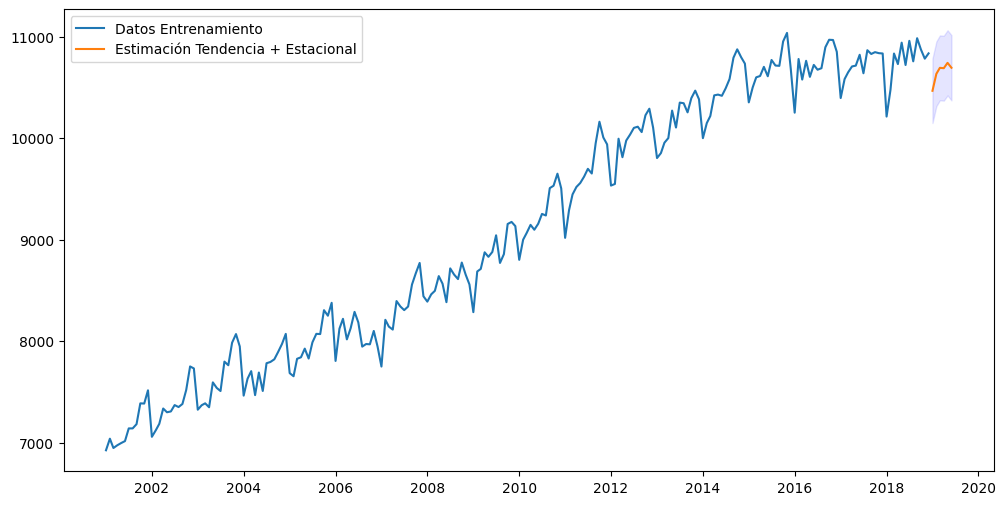

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.plot(y.index,y,label="Datos Entrenamiento")
plt.plot(preds.index,preds['Point_forecast'],label="Estimación Tendencia + Estacional")
plt.fill_between(preds.index,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [ ]:
rmse_add = np.sqrt(mean_squared_error(
    test_td, preds['Point_forecast']
))
print(rmse_add)

104.61370412228936


## Ya que encontramos el mejor modelo, volvemos a entrenar el modelo pero con train + test

In [ ]:
td_full = pd.concat([train_td, test_td], axis=0)

td_full = td_full.sort_index()

In [ ]:
y = td_full["Ocupados"]
td_full["x"] = np.linspace(1,td_full.shape[0],td_full.shape[0])
td_full["x2"] = td_full["x"]**2
td_full["x3"] = td_full["x"]**3

month_dummies = pd.get_dummies(td_full.index.month,drop_first=True, dtype=float).set_index(td_full.index)
X = sm.add_constant( pd.concat([td_full[["x","x2","x3"]],month_dummies],axis=1) )

season_pol3 = sm.OLS(y,X)
season_pol_3 = season_pol3.fit()
print(season_pol_3.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     1158.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          4.96e-188
Time:                        09:57:40   Log-Likelihood:                -1420.0
No. Observations:                 222   AIC:                             2870.
Df Residuals:                     207   BIC:                             2921.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6971.9175     51.941    134.228      0.0

## Regresión lineal

### Autocorrelación

In [ ]:
signo = train.y1>0